# Financial Performance Analysis of Netflix, Bilibili, and iQIYI

## Research Question
This notebook examines how the financial performance of a global streaming platform, Netflix, differs from that of two Chinese platforms, Bilibili and iQIYI. It also explores the relationship between user growth and revenue and considers how differences in business models help explain these financial outcomes.

## Project Overview

This notebook supports a **Track 4 Streamlit dashboard project** for ACC102. It compares **Netflix, Bilibili, and iQIYI** in three areas:

1. revenue scale and growth;
2. profitability; and
3. the relationship between user scale and revenue.

The notebook documents the data preparation and analysis behind the Streamlit app. The dashboard version makes the comparison easier to explore by changing years and viewing the three platforms side by side.


## Analytical Problem and Target User

This notebook addresses a practical business-analysis question: **how do Netflix, Bilibili, and iQIYI differ in revenue growth, profitability, and user monetisation?** The analysis is designed for **non-technical business students, beginner investors, and readers who want a clear comparison of streaming-platform performance without reading full annual reports**.

From an analytical perspective, the notebook focuses on three tasks:

1. comparing the financial scale and profitability of the three firms;
2. examining whether user growth is associated with revenue growth; and
3. explaining how differences in business models may help account for the financial outcomes.

The notebook is written as a reproducible analysis workflow for a GitHub-based project. The goal is not only to show code, but also to communicate a clear business conclusion from structured data.

## Data Sources

Financial data in this notebook were compiled from **official investor-relations disclosures** and reorganised into a consistent annual format for comparison. A secondary market-data source was used only to cross-check part of the Netflix revenue series.

### Main sources and access information
- **Netflix Investor Relations** – annual reports and investor materials  
  Accessed: **22 April 2026**  
  https://ir.netflix.net/financials/annual-reports-and-proxies/default.aspx

- **Bilibili Investor Relations** – financial information and annual disclosures  
  Accessed: **22 April 2026**  
  https://ir.bilibili.com/en/financial-information/

- **iQIYI Investor Relations** – annual reports and financial disclosures  
  Accessed: **22 April 2026**  
  https://ir.iqiyi.com/financial-information/annual-reports/

- **Macrotrends** – supplementary Netflix revenue series  
  Accessed: **22 April 2026**  
  https://www.macrotrends.net/stocks/charts/NFLX/netflix/revenue

### Files used in this notebook
- `data/netflix_financials.csv`
- `data/bilibili_financials.csv`
- `data/iqiyi_financials.csv`

The access dates are included so the sources can be checked again later if the data need to be updated.


## Methodology Note

This project uses a descriptive comparison rather than a forecasting model. The goal is to make the financial differences between the three platforms clear and easy to interpret.

- Revenue and net income are standardised to **million USD**.
- User metrics are standardised to **million users**.
- For Bilibili, **MAU (monthly active users)** is used instead of subscribers because Bilibili does not follow the same subscription-led model as Netflix.
- Profit margin is used to compare how effectively each company converts revenue into earnings.
- The dataset is designed for **comparative analysis**, not company valuation.


## Setup and Running Note

To reproduce this project correctly, keep the notebook, app file, and data files in the **same project folder**:

- `notebook.ipynb`
- `app.py`
- `README.md`
- `requirements.txt`
- `data/netflix_financials.csv`
- `data/bilibili_financials.csv`
- `data/iqiyi_financials.csv`

Then open the notebook in **Jupyter Notebook, JupyterLab, or VS Code**, and run the cells **from top to bottom**.

To run the dashboard locally, open a terminal in the project folder and use:

```bash
streamlit run app.py
```


## Data Cleaning and Comparability Decisions

Several preparation choices were made to improve comparability across firms:

- Monetary values were converted into a **common unit (million USD)**.
- Column names were standardized across datasets so the same analysis steps could be applied to each company.
- Profit margin was calculated as **NetIncome / Revenue**.
- Revenue growth was calculated using annual percentage change.
- Company datasets were kept separate during cleaning and then compared using common variables and summary tables.
- A comparability limitation remains: **Netflix and iQIYI are represented by subscribers, while Bilibili is represented by MAU** because directly comparable paid-subscriber data are not consistently available across the full sample.

These decisions are important because cross-country platform analysis can easily become misleading if accounting units, user metrics, or variable definitions are inconsistent.

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path

plt.rcParams["figure.figsize"] = (8, 5)

base = Path.cwd()
data_dir = base / "data"

def load_csv(filename):
    candidates = [
        data_dir / filename,
        base / filename,
        Path('/mnt/data') / filename,
    ]
    for p in candidates:
        if p.exists():
            return pd.read_csv(p)
    raise FileNotFoundError(f"Could not find {filename} in data/ or current directory.")

netflix = load_csv("netflix_financials.csv")
bilibili = load_csv("bilibili_financials.csv")
iqiyi = load_csv("iqiyi_financials.csv")


## Data Preview
The three datasets are organized in a consistent annual format so that the companies can be compared directly.

In [2]:
print("Netflix")
display(netflix)

print("Bilibili")
display(bilibili)

print("iQIYI")
display(iqiyi)

Netflix


,Year,Revenue,NetIncome,Subscribers
0,2018,15794,1211,139
1,2019,20156,1867,167
2,2020,24996,2761,203
3,2021,29698,5116,222
4,2022,31616,4491,231
5,2023,33723,5408,260


Bilibili


,Year,Revenue,NetIncome,MAU
0,2018,412,-86,92
1,2019,965,-193,130
2,2020,1838,-480,202
3,2021,3120,-1068,267
4,2022,3201,-750,326
5,2023,3500,-680,336


iQIYI


,Year,Revenue,NetIncome,Subscribers
0,2018,3600,-91,87
1,2019,4100,-1500,106
2,2020,4600,-1100,118
3,2021,4700,-900,97
4,2022,4300,170,101
5,2023,4400,300,105


## Data Coverage and Variable Structure

To improve comparability, each dataset is structured around the same core variables:

- **Year**
- **Revenue** (million USD)
- **NetIncome** (million USD)
- **Subscribers** or **MAU** (million users)

This makes it possible to compare scale, profitability, user expansion, and monetization patterns in a single analytical framework.

## Data Preparation

To compare operational efficiency across firms, profit margin is calculated as net income divided by revenue. Revenue growth is also calculated to show how quickly each platform expanded over time.

In [3]:
netflix["ProfitMargin"] = netflix["NetIncome"] / netflix["Revenue"]
bilibili["ProfitMargin"] = bilibili["NetIncome"] / bilibili["Revenue"]
iqiyi["ProfitMargin"] = iqiyi["NetIncome"] / iqiyi["Revenue"]

netflix["RevenueGrowth"] = netflix["Revenue"].pct_change()
bilibili["RevenueGrowth"] = bilibili["Revenue"].pct_change()
iqiyi["RevenueGrowth"] = iqiyi["Revenue"].pct_change()

## Descriptive Summary Table

Before turning to charts, it is useful to compare the three companies using a small set of summary indicators. These indicators capture scale, growth, and profitability in a compact form and make the later discussion easier to follow.

In [4]:
comparison_summary = pd.DataFrame({
    "Company": ["Netflix", "Bilibili", "iQIYI"],
    "Latest Revenue (USD mn)": [
        netflix["Revenue"].iloc[-1],
        bilibili["Revenue"].iloc[-1],
        iqiyi["Revenue"].iloc[-1]
    ],
    "Revenue CAGR": [
        (netflix["Revenue"].iloc[-1] / netflix["Revenue"].iloc[0]) ** (1 / (len(netflix) - 1)) - 1,
        (bilibili["Revenue"].iloc[-1] / bilibili["Revenue"].iloc[0]) ** (1 / (len(bilibili) - 1)) - 1,
        (iqiyi["Revenue"].iloc[-1] / iqiyi["Revenue"].iloc[0]) ** (1 / (len(iqiyi) - 1)) - 1
    ],
    "Average Profit Margin": [
        netflix["ProfitMargin"].mean(),
        bilibili["ProfitMargin"].mean(),
        iqiyi["ProfitMargin"].mean()
    ],
    "Latest Profit Margin": [
        netflix["ProfitMargin"].iloc[-1],
        bilibili["ProfitMargin"].iloc[-1],
        iqiyi["ProfitMargin"].iloc[-1]
    ]
})

comparison_summary["Revenue CAGR"] = comparison_summary["Revenue CAGR"].map(lambda x: f"{x:.2%}")
comparison_summary["Average Profit Margin"] = comparison_summary["Average Profit Margin"].map(lambda x: f"{x:.2%}")
comparison_summary["Latest Profit Margin"] = comparison_summary["Latest Profit Margin"].map(lambda x: f"{x:.2%}")

display(comparison_summary)

,Company,Latest Revenue (USD mn),Revenue CAGR,Average Profit Margin,Latest Profit Margin
0,Netflix,33723,16.38%,12.57%,16.04%
1,Bilibili,3500,53.40%,-24.01%,-19.43%
2,iQIYI,4400,4.10%,-11.90%,6.82%


### Discussion

This table provides an immediate snapshot of the strategic contrast across the three firms. A high revenue base indicates scale, revenue CAGR captures expansion speed, and profit margin reflects the firm's ability to convert revenue into earnings.

Taken together, these indicators allow the analysis to move beyond simple size comparison. A platform may grow quickly but still struggle with profitability, or it may operate at large scale with strong earnings discipline. This distinction is central to the comparison between Netflix, Bilibili, and iQIYI.

## Revenue Comparison
The first comparison focuses on revenue scale and overall growth trends across the three companies.

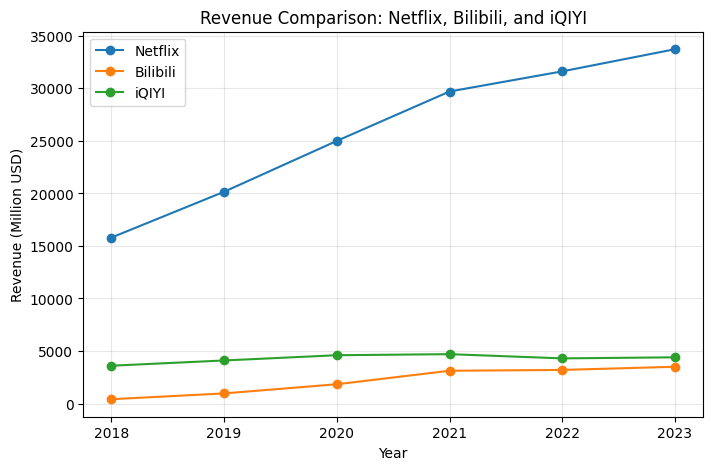

In [5]:
plt.figure()
plt.plot(netflix["Year"], netflix["Revenue"], marker="o", label="Netflix")
plt.plot(bilibili["Year"], bilibili["Revenue"], marker="o", label="Bilibili")
plt.plot(iqiyi["Year"], iqiyi["Revenue"], marker="o", label="iQIYI")
plt.xlabel("Year")
plt.ylabel("Revenue (Million USD)")
plt.title("Revenue Comparison: Netflix, Bilibili, and iQIYI")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Extended Interpretation

The revenue chart should be read from both a **scale** and a **growth** perspective. Netflix's leading position reflects not only its early international expansion, but also the efficiency of a subscription-led revenue model that converts global reach into recurring income.

Bilibili's trajectory is important because it shows that smaller firms can still achieve substantial top-line growth. However, the chart also indicates that growth from a lower base does not necessarily close the gap with a global incumbent.

iQIYI's more moderate trend suggests a platform facing structural pressure: it participates in a large domestic market, yet revenue performance appears more constrained by competition, monetization limits, or strategic adjustment.

## Revenue Growth Comparison

Looking at levels alone can hide changes in momentum. Revenue growth rates help identify whether a platform is accelerating, stabilizing, or losing pace over time.

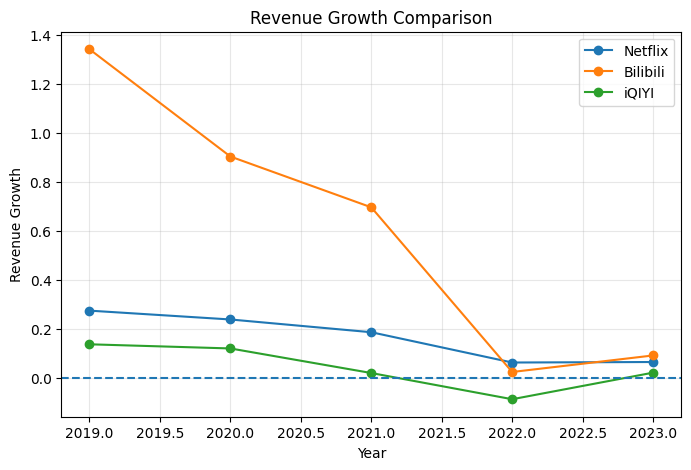

In [6]:
plt.figure()
plt.plot(netflix["Year"], netflix["RevenueGrowth"], marker="o", label="Netflix")
plt.plot(bilibili["Year"], bilibili["RevenueGrowth"], marker="o", label="Bilibili")
plt.plot(iqiyi["Year"], iqiyi["RevenueGrowth"], marker="o", label="iQIYI")
plt.axhline(0, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Revenue Growth")
plt.title("Revenue Growth Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Discussion

Revenue growth rates add a dynamic dimension to the analysis. Even when a firm's revenue remains large, slowing growth may indicate market saturation or strategic transition. By contrast, strong growth from a smaller platform may reflect successful expansion, but not necessarily durable financial strength.

If the growth series is volatile, that volatility itself is meaningful. It may suggest a revenue model that is more sensitive to content cycles, advertising conditions, or changes in user monetization.

### Discussion

Netflix has the largest revenue base by a wide margin and shows steady growth across the full sample period. This suggests that its global subscription model produces both scale and stability.

Bilibili starts from a much smaller base but records strong expansion over time. Even so, its total revenue remains well below Netflix, which indicates that rapid growth does not necessarily translate into comparable scale.

iQIYI's revenue trend is more moderate. Compared with Netflix and Bilibili, its revenue growth appears weaker after 2021, which may reflect slower expansion or strategic adjustment.

## Net Income Comparison
Revenue alone does not show whether a firm is financially successful. Net income provides a direct view of profitability.

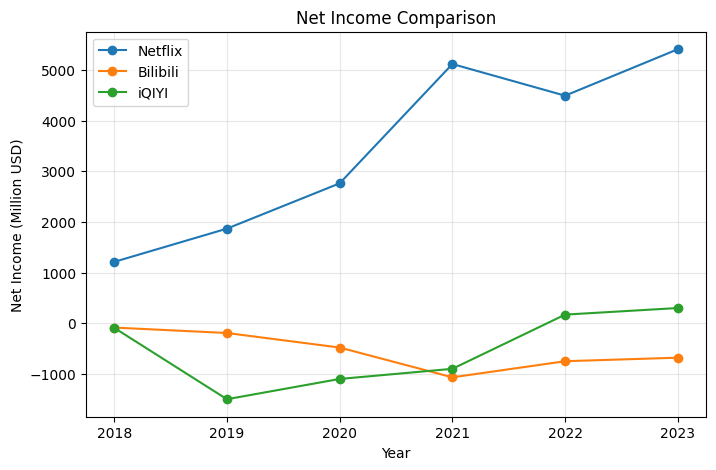

In [7]:
plt.figure()
plt.plot(netflix["Year"], netflix["NetIncome"], marker="o", label="Netflix")
plt.plot(bilibili["Year"], bilibili["NetIncome"], marker="o", label="Bilibili")
plt.plot(iqiyi["Year"], iqiyi["NetIncome"], marker="o", label="iQIYI")
plt.xlabel("Year")
plt.ylabel("Net Income (Million USD)")
plt.title("Net Income Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Extended Interpretation

Net income is especially important in platform industries because scale alone can be misleading. A company may attract users and generate revenue while still destroying value if content spending, customer acquisition cost, or operating expenses remain too high.

Netflix's ability to remain profitable suggests a business model in which user scale and revenue scale are already large enough to absorb content and operating costs. Bilibili and iQIYI, in different ways, illustrate how difficult it can be to turn audience growth into bottom-line performance.

### Discussion

Netflix remains profitable throughout the period. Its ability to maintain positive net income while expanding revenue highlights the strength of its monetization model.

Bilibili records losses in every year in the sample. This indicates that user growth and revenue growth have not yet been converted into sustainable profitability.

iQIYI presents a more transitional pattern. After several years of losses, it turns profitable in the later years, which suggests stronger cost control and a more disciplined operating strategy.

## Profit Margin Comparison
Profit margin helps compare efficiency more clearly because it measures profit relative to revenue rather than profit in absolute size.

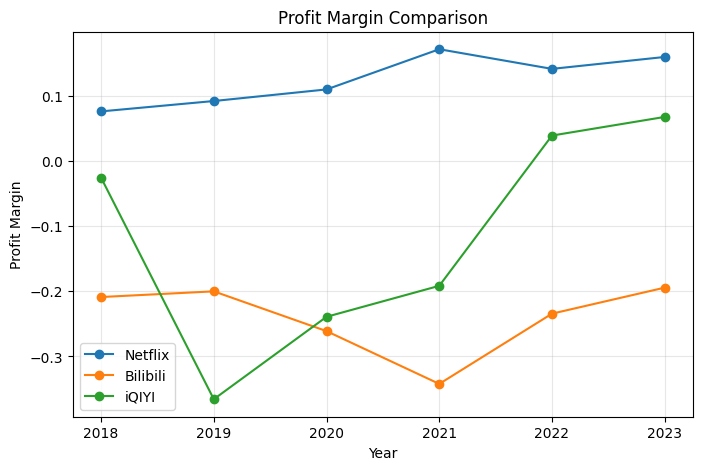

In [8]:
plt.figure()
plt.plot(netflix["Year"], netflix["ProfitMargin"], marker="o", label="Netflix")
plt.plot(bilibili["Year"], bilibili["ProfitMargin"], marker="o", label="Bilibili")
plt.plot(iqiyi["Year"], iqiyi["ProfitMargin"], marker="o", label="iQIYI")
plt.xlabel("Year")
plt.ylabel("Profit Margin")
plt.title("Profit Margin Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Extended Interpretation

Profit margin gives a cleaner comparison than net income alone because it controls for differences in size. A smaller company can still be efficient if it preserves margins, while a large company may reveal weakness if revenue rises without earnings support.

In the context of this project, margin trends are useful because they connect directly to business model design. A platform with stronger pricing power, lower customer churn, or better cost discipline should usually exhibit more stable margins over time.

## Operating Profile by Firm

The table below combines growth, profitability, and user metrics into a concise operating profile for each company. This is useful for both written analysis and presentation purposes because it turns multiple charts into one summary view.

In [9]:
def latest_user_metric(df):
    if "Subscribers" in df.columns:
        return df["Subscribers"].iloc[-1], "Subscribers"
    return df["MAU"].iloc[-1], "MAU"

netflix_user, netflix_metric = latest_user_metric(netflix)
bilibili_user, bilibili_metric = latest_user_metric(bilibili)
iqiyi_user, iqiyi_metric = latest_user_metric(iqiyi)

profile = pd.DataFrame({
    "Company": ["Netflix", "Bilibili", "iQIYI"],
    "Primary User Metric": [netflix_metric, bilibili_metric, iqiyi_metric],
    "Latest User Base (mn)": [netflix_user, bilibili_user, iqiyi_user],
    "Latest Revenue (USD mn)": [
        netflix["Revenue"].iloc[-1],
        bilibili["Revenue"].iloc[-1],
        iqiyi["Revenue"].iloc[-1]
    ],
    "Latest Net Income (USD mn)": [
        netflix["NetIncome"].iloc[-1],
        bilibili["NetIncome"].iloc[-1],
        iqiyi["NetIncome"].iloc[-1]
    ]
})

display(profile)

,Company,Primary User Metric,Latest User Base (mn),Latest Revenue (USD mn),Latest Net Income (USD mn)
0,Netflix,Subscribers,260,33723,5408
1,Bilibili,MAU,336,3500,-680
2,iQIYI,Subscribers,105,4400,300


### Discussion

Netflix maintains consistently positive margins, showing that it monetizes its revenue base efficiently.

Bilibili's margins stay negative across the full period. This suggests that its growth strategy has relied heavily on investment and ecosystem expansion rather than short-term earnings performance.

iQIYI's margin improves substantially over time. The shift into positive territory in the later years suggests that profitability depends not only on revenue growth, but also on operating discipline and business model adjustment.

## User Growth and Revenue
The next step is to examine whether user growth is closely associated with revenue growth.

For Netflix and iQIYI, the relevant user metric is the number of subscribers. For Bilibili, the more suitable operating metric is MAU.

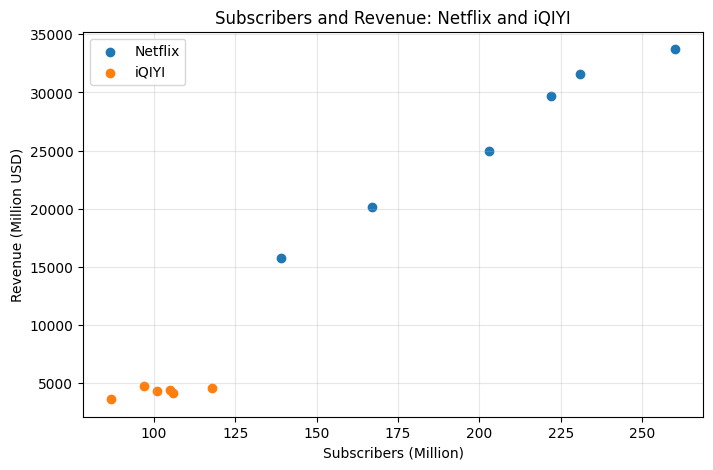

In [10]:
plt.figure()
plt.scatter(netflix["Subscribers"], netflix["Revenue"], label="Netflix")
plt.scatter(iqiyi["Subscribers"], iqiyi["Revenue"], label="iQIYI")
plt.xlabel("Subscribers (Million)")
plt.ylabel("Revenue (Million USD)")
plt.title("Subscribers and Revenue: Netflix and iQIYI")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

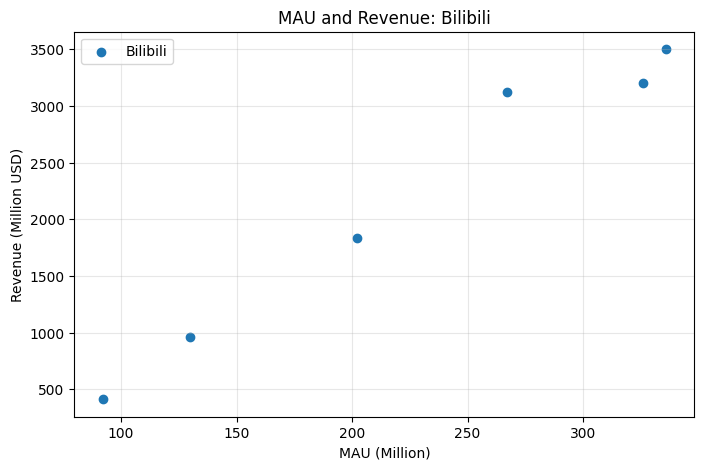

In [11]:
plt.figure()
plt.scatter(bilibili["MAU"], bilibili["Revenue"], label="Bilibili")
plt.xlabel("MAU (Million)")
plt.ylabel("Revenue (Million USD)")
plt.title("MAU and Revenue: Bilibili")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Correlation Between User Scale and Revenue

A scatter plot gives a visual impression of the relationship between users and revenue, but a simple correlation coefficient helps summarize the strength of that association more directly.

In [12]:
netflix_corr = netflix["Subscribers"].corr(netflix["Revenue"])
iqiyi_corr = iqiyi["Subscribers"].corr(iqiyi["Revenue"])
bilibili_corr = bilibili["MAU"].corr(bilibili["Revenue"])

correlation_table = pd.DataFrame({
    "Company": ["Netflix", "Bilibili", "iQIYI"],
    "User Metric": ["Subscribers", "MAU", "Subscribers"],
    "Correlation with Revenue": [netflix_corr, bilibili_corr, iqiyi_corr]
})

display(correlation_table)

,Company,User Metric,Correlation with Revenue
0,Netflix,Subscribers,0.990741
1,Bilibili,MAU,0.985067
2,iQIYI,Subscribers,0.627048


### Discussion

Correlation does not prove causality, but it is still informative here. A high positive value suggests that user expansion and revenue expansion move together closely. A weaker value suggests that user scale alone cannot fully explain financial performance.

This distinction is central to the project. Netflix would be expected to show a tighter user–revenue relationship because subscriptions are the core of its business model, whereas Bilibili and iQIYI operate with more complex revenue structures.

### Discussion

Netflix shows a strong positive relationship between subscriber growth and revenue. This is consistent with a business model that depends heavily on paying users.

Bilibili also shows simultaneous growth in MAU and revenue, but the relationship is more complex. Its revenue comes from multiple business segments, so higher user engagement does not translate into a simple subscription-based pattern.

iQIYI shows a weaker and less stable relationship between subscribers and revenue than Netflix. This suggests that user scale alone is not enough; the efficiency of monetization also matters.

## Business Model Comparison

### Netflix
- Primarily subscription-based
- Revenue is closely tied to paying subscribers
- Strong monetization efficiency and global scale

### Bilibili
- More diversified model, including advertising, gaming, live streaming, and value-added services
- Strong user engagement and platform ecosystem
- Growth in users does not automatically produce profitability

### iQIYI
- Hybrid model based on subscription and advertising
- Weaker financial performance than Netflix, but improving profitability over time
- Represents a more transitional case within the Chinese streaming market

## Integrated Findings

The preceding charts and tables lead to three broader findings.

**First, scale and profitability do not move together automatically.** Netflix combines both, but Bilibili demonstrates that strong user and revenue growth can coexist with persistent losses.

**Second, the user–revenue relationship depends on monetization design.** In a subscription-heavy model, additional paying users are more likely to translate directly into revenue. In diversified platform models, the link is weaker because revenue depends on several channels at once.

**Third, business model differences help explain cross-country platform outcomes.** The global platform in this comparison relies on a more focused and scalable revenue mechanism, while the Chinese platforms operate in a more mixed and operationally demanding environment.

## Demo Notes for the Track 4 Video

The demo video can use the Streamlit dashboard as the main screen, while this notebook can be mentioned as the supporting analysis file.

1. **Research question and motivation**  
   Start by explaining that the project compares Netflix, Bilibili, and iQIYI to understand how global and Chinese streaming platforms differ in revenue, profitability, and monetization.

2. **Data and method**  
   Briefly show that the project uses annual investor-relations data. Mention that the data were standardised into million USD and million users so the companies can be compared more clearly.

3. **Dashboard navigation**  
   Show the sidebar controls and explain that the user can change the selected year or compare all years. This demonstrates the interactive part of the Track 4 submission.

4. **Netflix result**  
   Use the revenue and profit charts to show that Netflix has the largest revenue base and the strongest profitability. Link this to its subscription-led business model and global scale.

5. **Bilibili result**  
   Show Bilibili's revenue, MAU, and profit trend. Explain that Bilibili has strong user engagement, but its diversified platform model does not automatically create profits.

6. **iQIYI result**  
   Point out that iQIYI is smaller than Netflix but shows improvement in profitability in the later years. Explain that this makes it a useful middle case between Netflix and Bilibili.

7. **Final takeaway**  
   End by saying that user growth matters, but the business model determines whether those users can be converted into sustainable revenue and profit.


## Conclusion

This analysis shows clear differences between the global platform and the two Chinese platforms.

Netflix demonstrates the strongest financial performance by a wide margin. It combines large and growing revenue with consistent profitability, which reflects the effectiveness of its subscription-based model.

Bilibili shows that rapid expansion in users and revenue does not necessarily lead to profits. Its financial pattern is more consistent with a platform focused on ecosystem growth and engagement than on short-term earnings.

iQIYI occupies a middle position. It remains smaller and less efficient than Netflix, but its movement toward profitability suggests that business model adjustment and cost control can materially improve performance.

Overall, the findings suggest that financial outcomes depend not only on user growth, but also on how effectively a platform converts user activity into revenue and profit.

## Final Comparative Summary

The following table translates the empirical results into a concise strategic comparison.

In [13]:
final_summary = pd.DataFrame({
    "Company": ["Netflix", "Bilibili", "iQIYI"],
    "Revenue Scale": ["High", "Medium", "Medium to Low"],
    "Profitability": ["Strong", "Weak", "Improving"],
    "User-Revenue Link": ["Strong", "Moderate / Complex", "Weaker"],
    "Business Model": [
        "Subscription-led",
        "Diversified platform model",
        "Hybrid subscription + advertising"
    ]
})

display(final_summary)

,Company,Revenue Scale,Profitability,User-Revenue Link,Business Model
0,Netflix,High,Strong,Strong,Subscription-led
1,Bilibili,Medium,Weak,Moderate / Complex,Diversified platform model
2,iQIYI,Medium to Low,Improving,Weaker,Hybrid subscription + advertising


## Suggestions for Further Research

This notebook focuses on broad firm-level comparison. Future work could deepen the analysis in several ways:

- adding **ARPU** or segment revenue data to compare monetization efficiency more precisely;
- separating domestic and international performance where disclosures allow;
- examining content expenditure, marketing intensity, or cash flow to explain why profitability differs across platforms;
- extending the sample period to test whether recent strategic changes are temporary or structural.

These extensions would strengthen the causal interpretation of the observed patterns and provide a more detailed view of platform strategy.

## Critical Reflection

A limitation of this notebook is that the user metrics are not perfectly identical across firms. Netflix and iQIYI are represented by subscribers, while Bilibili is represented by MAU. This means the comparison is useful for broad platform analysis, but it is not a perfectly like-for-like measure. A more advanced version of the study could incorporate segment revenue or ARPU data.

## Reproducibility Note for the GitHub Project

The GitHub repository should keep the notebook, Streamlit app, data files, and documentation together in a clear structure:

- `notebook.ipynb`
- `app.py`
- `README.md`
- `requirements.txt`
- `data/netflix_financials.csv`
- `data/bilibili_financials.csv`
- `data/iqiyi_financials.csv`
- `outputs/` for any exported charts or summary tables

This notebook shows the full analysis workflow. The Streamlit app presents the same project in a more interactive format for the Track 4 dashboard.


## References

Netflix Investors. *Annual Reports & Proxies*. Accessed 22 April 2026.  
https://ir.netflix.net/financials/annual-reports-and-proxies/default.aspx

Bilibili Investor Relations. *Financial Information*. Accessed 22 April 2026.  
https://ir.bilibili.com/en/financial-information/

iQIYI Investor Relations. *Annual Reports*. Accessed 22 April 2026.  
https://ir.iqiyi.com/financial-information/annual-reports/

Macrotrends. *Netflix Revenue*. Accessed 22 April 2026.  
https://www.macrotrends.net/stocks/charts/NFLX/netflix/revenue